# EDA Zonas Salva - Sonora 2026

Este notebook explora la base de datos de Zonas Salva, que son establecimientos (bares, restaurantes, tiendas) adheridos a un programa de seguridad municipal. La ubicacion geografica y tipo de establecimiento pueden correlacionar con incidencia delictiva. Este es un dataset estatico con informacion de enero y febrero 2026.

## 1. Importaciones y Carga de Datos

Se cargan ambos archivos mensuales de Zonas Salva (enero y febrero 2026). Se verifica la consistencia entre meses y se consolida en un dataset unico para el analisis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Rutas
RAW = Path("../data/raw/zonas_salva")

# Estilo
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

# Cargar ambos meses
df_ene = pd.read_excel(RAW / "Zonas Salva enero 2026.xlsx", sheet_name=0)
df_feb = pd.read_excel(RAW / "Zonas Salva febrero 2026.xlsx", sheet_name=0)

print(f"Enero 2026: {df_ene.shape}")
print(f"Febrero 2026: {df_feb.shape}")

# Usar enero como principal (mismo universo de establecimientos)
df_salva = df_ene.copy()
print(f"\nDataset principal (enero): {df_salva.shape}")
print(f"\nPrimeras filas:")
df_salva.head()

Enero 2026: (3132, 24)
Febrero 2026: (3191, 24)

Dataset principal (enero): (3132, 24)

Primeras filas:


,DESCRIPCION_LUGAR,LATITUD,LONGITUD,MUNICIPIO,LOCALIDAD,COLONIA,CALLE,NUMERO,ENTRE_CALLES,TIPO_LUGAR,...,MIERCOLES_INICIO,MIERCOLES_FIN,JUEVES_INICIO,JUEVES_FIN,VIERNES_INICIO,VIERNES_FIN,SABADO_INICIO,SABADO_FIN,DOMINGO_INICIO,DOMINGO_FIN
0,C5I,29.06485956,-111.048098,HERMOSILLO,HERMOSILLO,LA MANGA,JUAN ANTONIO RUIBAL CORELLA,S/N,NaN,GOBIERNO,...,00:01:00,23:59:00,00:01:00,23:59:00,00:01:00,23:59:00,00:01:00,23:59:00,00:01:00,23:59:00
1,KEBURROS EXPRESS,29.0856107,-110.990879,HERMOSILLO,HERMOSILLO,SANTA FE,BLVD. LUIS DONALDO COLOSIO MURRIETA,617,BLVD. LAS QUINTAS Y DE LAS CRUCES,RESTAURANTE,...,19:00:00,02:30:00,19:00:00,02:30:00,19:00:00,04:30:00,19:00:00,04:30:00,19:00:00,02:30:00
2,KEBURROS COLOSIO,29.08436939,-110.979510,HERMOSILLO,HERMOSILLO,VILLA SATELITE,BLVD. LUIS DONALDO COLOSIO MURRIETA,413,NaN,RESTAURANTE,...,12:00:00,03:00:00,12:00:00,03:00:00,12:00:00,05:00:00,12:00:00,05:00:00,12:00:00,03:00:00
3,KEBURROS PITIC,29.09884,-110.950610,HERMOSILLO,HERMOSILLO,PITIC,AV. IGNACIO MARISCAL,18,BLVD. GÓMEZ FARÍAS Y BLVD. MORELOS,RESTAURANTE,...,12:00:00,03:00:00,12:00:00,03:00:00,12:00:00,05:00:00,12:00:00,05:00:00,12:00:00,03:00:00
4,KEBURROS MORELOS,29.11623,-110.950780,HERMOSILLO,HERMOSILLO,LOMA LINDA,BLVD. JOSE MARIA MORELOS,281,NaN,RESTAURANTE,...,12:00:00,03:00:00,12:00:00,03:00:00,12:00:00,05:00:00,12:00:00,05:00:00,12:00:00,03:00:00


## 2. Exploracion Inicial - Estructura y Calidad

Se analiza la estructura basica: cobertura municipal, tipos de establecimientos, calidad de datos (valores nulos). Zonas Salva son lugares considerados seguros por la policia local, por lo que su distribucion espacial puede ser indicador inverso de riesgo.

In [3]:
print("=" * 60)
print("INFORMACION GENERAL")
print("=" * 60)

print(f"\nShape: {df_salva.shape}")
print(f"Establecimientos: {len(df_salva)}")
print(f"Municipios: {df_salva['MUNICIPIO'].nunique()}")
print(f"Localidades: {df_salva['LOCALIDAD'].nunique()}")
print(f"Colonias: {df_salva['COLONIA'].nunique()}")
print(f"Tipos de lugares: {df_salva['TIPO_LUGAR'].nunique()}")

print(f"\nValores nulos por columna:")
nulos = df_salva.isnull().sum()
print(nulos[nulos > 0])

print(f"\nPorcentaje de completitud por campo geografico:")
print(f"  Municipio: {(df_salva['MUNICIPIO'].notna().sum()/len(df_salva)*100):.1f}%")
print(f"  Localidad: {(df_salva['LOCALIDAD'].notna().sum()/len(df_salva)*100):.1f}%")
print(f"  Colonia: {(df_salva['COLONIA'].notna().sum()/len(df_salva)*100):.1f}%")
print(f"  Calle: {(df_salva['CALLE'].notna().sum()/len(df_salva)*100):.1f}%")
print(f"  Coordenadas (Latitud+Longitud): {(df_salva['LATITUD'].notna().sum()/len(df_salva)*100):.1f}%")

INFORMACION GENERAL

Shape: (3132, 24)
Establecimientos: 3132
Municipios: 72
Localidades: 128
Colonias: 762
Tipos de lugares: 7

Valores nulos por columna:
COLONIA            14
CALLE              16
NUMERO            122
ENTRE_CALLES      272
LUNES_FIN           1
MARTES_FIN          1
DOMINGO_INICIO      1
DOMINGO_FIN         1
dtype: int64

Porcentaje de completitud por campo geografico:
  Municipio: 100.0%
  Localidad: 100.0%
  Colonia: 99.6%
  Calle: 99.5%
  Coordenadas (Latitud+Longitud): 100.0%


## 3. Distribucion Municipal - Donde estan las Zonas Salva

Se identifican los municipios con mayor concentracion de establecimientos en el programa. Esto es importante para entender la cobertura de seguridad municipal y puede ser variable de contexto para el modelo de delincuencia.

Top 15 municipios por cantidad de Zonas Salva:
MUNICIPIO
HERMOSILLO               1427
CAJEME                    576
NOGALES                   153
EMPALME                   140
SAN LUIS RIO COLORADO     123
CANANEA                   123
GUAYMAS                   105
NAVOJOA                    88
CABORCA                    82
PUERTO PEÑASCO             48
AGUA PRIETA                42
HUATABAMPO                 23
ALAMOS                     22
BACUM                      14
ETCHOJOA                   13
Name: count, dtype: int64


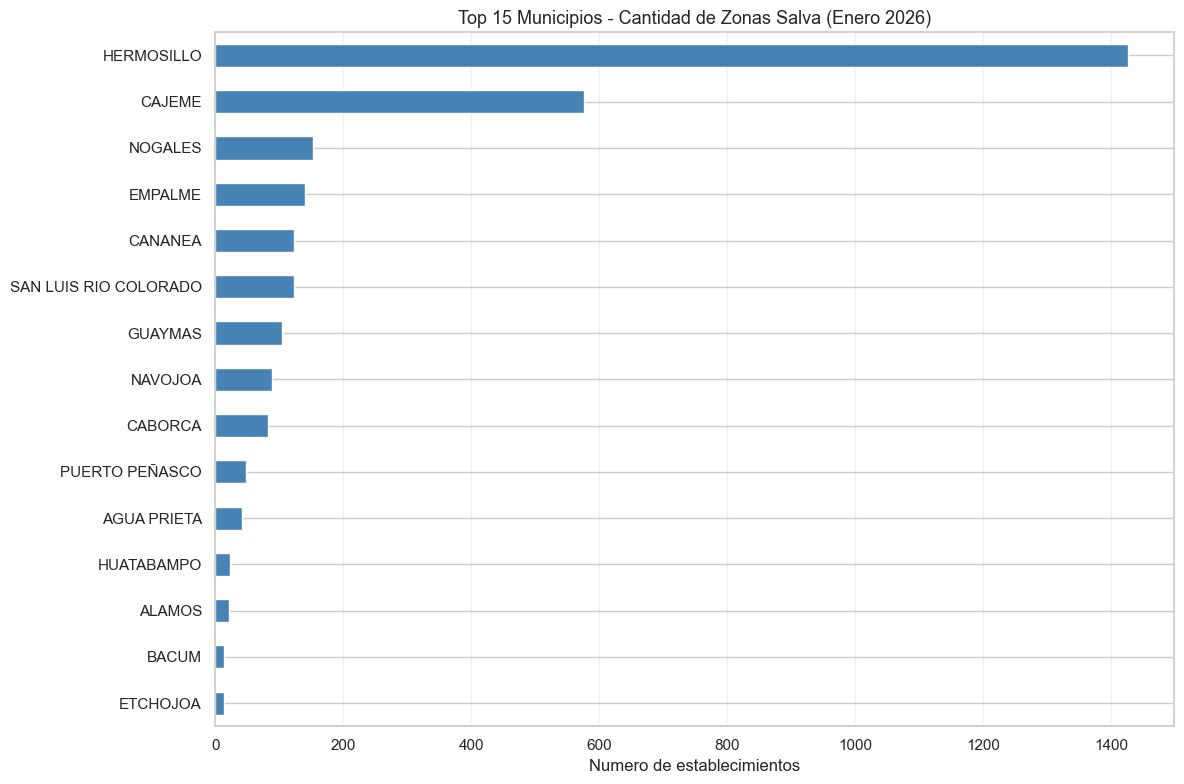


Top 5 municipios concentran: 77.2% de las Zonas Salva


In [4]:
# Distribucion por municipio
mun_dist = df_salva['MUNICIPIO'].value_counts()

print(f"Top 15 municipios por cantidad de Zonas Salva:")
print(mun_dist.head(15))

# Grafica
fig, ax = plt.subplots(figsize=(12, 8))
mun_dist.head(15).sort_values(ascending=True).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Municipios - Cantidad de Zonas Salva (Enero 2026)', fontsize=13)
ax.set_xlabel('Numero de establecimientos')
ax.set_ylabel('')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Concentracion
top5_total = mun_dist.head(5).sum()
total = mun_dist.sum()
print(f"\nTop 5 municipios concentran: {(top5_total/total)*100:.1f}% de las Zonas Salva")

## 4. Tipos de Establecimientos - Clasificacion Funcional

Se analiza la distribucion de tipos de establecimientos en el programa Zonas Salva. El tipo de lugar (bar, tienda, restaurante, etc.) puede tener relacion con patrones de delincuencia específicos.

Distribucion por tipo de lugar:
  COMERCIO                        2120 ( 67.7%)
  GOBIERNO                         458 ( 14.6%)
  RESTAURANTE                      221 (  7.1%)
  ESCUELA                          191 (  6.1%)
  SALUD                             89 (  2.8%)
  ASOCIACION CIVIL                  38 (  1.2%)
  HOTEL                             15 (  0.5%)


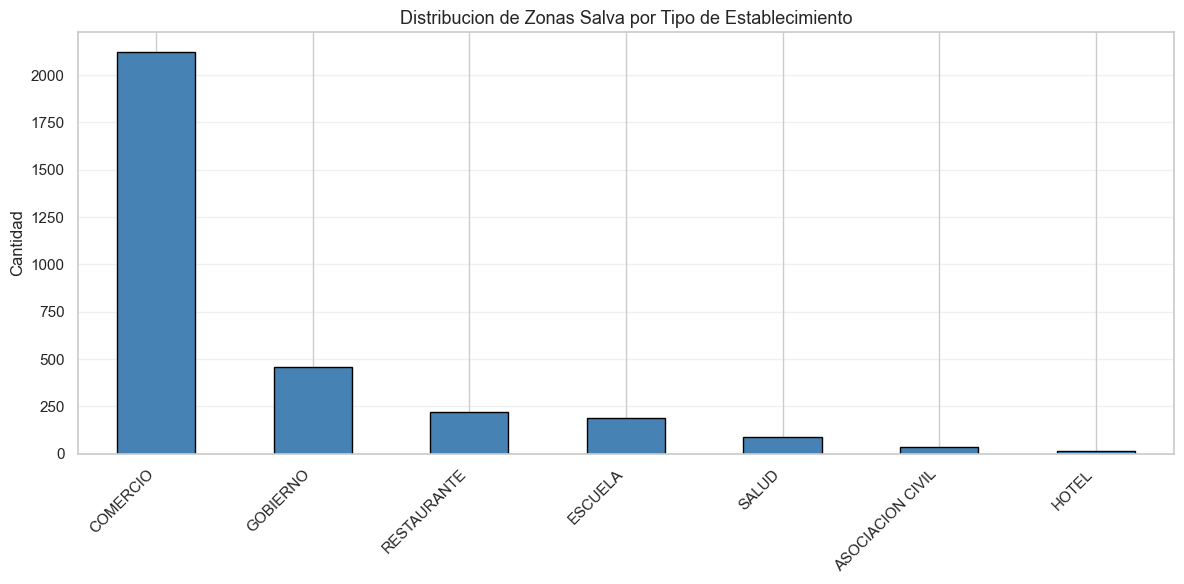

In [5]:
# Tipos de establecimientos
tipo_dist = df_salva['TIPO_LUGAR'].value_counts()

print(f"Distribucion por tipo de lugar:")
for tipo, cantidad in tipo_dist.items():
    pct = (cantidad / len(df_salva)) * 100
    print(f"  {tipo:30} {cantidad:5} ({pct:5.1f}%)")

# Grafica
fig, ax = plt.subplots(figsize=(12, 6))
tipo_dist.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Distribucion de Zonas Salva por Tipo de Establecimiento', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Cantidad')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5. Cobertura Geografica - Municipios con Zonas Salva

Se verifica la cobertura geografica del programa. Municipios sin Zonas Salva pueden indicar areas con menos presencia de establecimientos comerciales (areas rurales) o menos participacion en programas de seguridad.

In [6]:
municipios_con_salva = df_salva['MUNICIPIO'].nunique()
print(f"Municipios con al menos una Zona Salva: {municipios_con_salva}")
print(f"\nMunicipios cubiertos:")
print(sorted(df_salva['MUNICIPIO'].unique()))

# Crear distribucion de establecimientos por municipio (estadistico)
stats_mun = df_salva.groupby('MUNICIPIO').agg({
    'DESCRIPCION_LUGAR': 'count',
    'COLONIA': 'nunique',
    'TIPO_LUGAR': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'N/A'
}).rename(columns={
    'DESCRIPCION_LUGAR': 'Total_Establecimientos',
    'COLONIA': 'Num_Colonias',
    'TIPO_LUGAR': 'Tipo_Predominante'
}).sort_values('Total_Establecimientos', ascending=False)

print(f"\nEstadisticas por municipio (Top 10):")
print(stats_mun.head(10))

Municipios con al menos una Zona Salva: 72

Municipios cubiertos:
['ACONCHI', 'AGUA PRIETA', 'ALAMOS', 'ALTAR', 'ARIVECHI', 'ARIZPE', 'ATIL', 'BACADEHUACHI', 'BACANORA', 'BACERAC', 'BACOACHI', 'BACUM', 'BANAMICHI', 'BAVIACORA', 'BAVISPE', 'BENITO JUAREZ', 'BENJAMIN HILL', 'CABORCA', 'CAJEME', 'CANANEA', 'CARBO', 'CUCURPE', 'CUMPAS', 'DIVISADEROS', 'EMPALME', 'ETCHOJOA', 'FRONTERAS', 'GENERAL PLUTARCO ELIAS CALLES', 'GRANADOS', 'GUAYMAS', 'HERMOSILLO', 'HUACHINERA', 'HUASABAS', 'HUATABAMPO', 'HUEPAC', 'IMURIS', 'LA COLORADA', 'MAGDALENA', 'MAZATAN', 'MOCTEZUMA', 'NACO', 'NACORI CHICO', 'NACOZARI DE GARCIA', 'NAVOJOA', 'NOGALES', 'ONAVAS', 'OPODEPE', 'OQUITOA', 'PITIQUITO', 'PUERTO PEÑASCO', 'QUIRIEGO', 'RAYON', 'ROSARIO', 'SAHUARIPA', 'SAN FELIPE DE JESUS', 'SAN IGNACIO RIO MUERTO', 'SAN JAVIER', 'SAN LUIS RIO COLORADO', 'SAN MIGUEL DE HORCASITAS', 'SAN PEDRO DE LA CUEVA', 'SANTA ANA', 'SANTA CRUZ', 'SARIC', 'SOYOPA', 'SUAQUI GRANDE', 'TEPACHE', 'TRINCHERAS', 'TUBUTAMA', 'URES', 'VILLA 

## 6. Horarios de Operacion - Patrones de Seguridad

Se analiza la variabilidad de horarios entre establecimientos. Lugares que cierran temprano vs 24 horas pueden indicar dinamicas diferentes de seguridad. Se identifica patrones de cobertura temporal.

In [7]:
# Analizar patrones de horario
# Categorizar establecimientos por horario

def es_24_horas(row):
    """Verifica si el lugar opera 24 horas (horarios incluyen 00:01 - 23:59)"""
    dias = ['LUNES', 'MARTES', 'MIERCOLES', 'JUEVES', 'VIERNES', 'SABADO', 'DOMINGO']
    for dia in dias:
        inicio = row.get(f'{dia}_INICIO', None)
        fin = row.get(f'{dia}_FIN', None)
        if pd.isna(inicio) or pd.isna(fin):
            return False
        if str(inicio).strip() == '00:01:00' and str(fin).strip() == '23:59:00':
            return True
    return False

df_salva['Es_24_horas'] = df_salva.apply(es_24_horas, axis=1)

print(f"Establecimientos por patron de horario:")
print(f"  24 horas: {df_salva['Es_24_horas'].sum()}")
print(f"  Con horario variable: {(~df_salva['Es_24_horas']).sum()}")
print(f"\nPorcentaje 24h: {(df_salva['Es_24_horas'].sum()/len(df_salva)*100):.1f}%")

# Comparar entre municipios principales
mun_principales = df_salva['MUNICIPIO'].value_counts().head(5).index
print(f"\nProporcion 24 horas por municipio principal:")
for mun in mun_principales:
    subset = df_salva[df_salva['MUNICIPIO'] == mun]
    pct_24h = (subset['Es_24_horas'].sum() / len(subset)) * 100
    print(f"  {mun:20} {pct_24h:5.1f}%")

Establecimientos por patron de horario:
  24 horas: 252
  Con horario variable: 2880

Porcentaje 24h: 8.0%

Proporcion 24 horas por municipio principal:
  HERMOSILLO            10.7%
  CAJEME                 3.0%
  NOGALES                7.2%
  EMPALME                0.7%
  SAN LUIS RIO COLORADO   0.8%


## 7. Analisis Tipo x Municipio - Perfiles de Cobertura

Se cruza informacion de tipos de establecimientos y municipios. Diferentes municipios pueden tener perfiles distintos: algunos dominados por bares (vida nocturna riesgosa), otros por tiendas (comercio diario).

Distribucion de tipos de lugar por municipio principal:
TIPO_LUGAR             ASOCIACION CIVIL  COMERCIO  ESCUELA  GOBIERNO  HOTEL  \
MUNICIPIO                                                                     
HERMOSILLO                           13      1036       44       211      3   
CAJEME                                4       433       19        35      2   
NOGALES                               4        98       12        26      0   
EMPALME                               1       111        5        12      0   
SAN LUIS RIO COLORADO                 2        85       21         9      0   
CANANEA                               4        84        4         8      0   
GUAYMAS                               2        67        9        17      0   
NAVOJOA                               3        41       16        21      0   
CABORCA                               1        61        4         9      0   
PUERTO PEÑASCO                        0        13        5        26      2

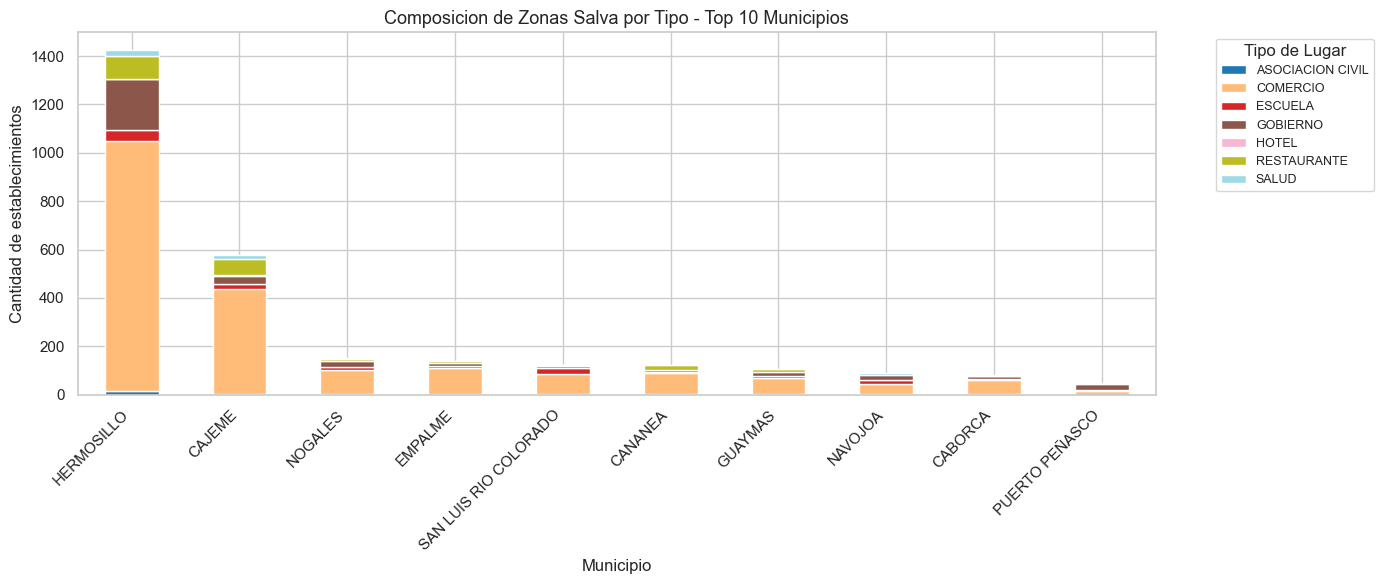

In [8]:
# Tabla cruzada: Municipio x Tipo de Lugar
crosstab = pd.crosstab(df_salva['MUNICIPIO'], df_salva['TIPO_LUGAR'])

# Mostrar los municipios principales
mun_top = df_salva['MUNICIPIO'].value_counts().head(10).index
crosstab_top = crosstab.loc[mun_top]

print("Distribucion de tipos de lugar por municipio principal:")
print(crosstab_top)

# Grafica de pila
fig, ax = plt.subplots(figsize=(14, 6))
crosstab_top.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_title('Composicion de Zonas Salva por Tipo - Top 10 Municipios', fontsize=13)
ax.set_xlabel('Municipio')
ax.set_ylabel('Cantidad de establecimientos')
ax.legend(title='Tipo de Lugar', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 8. Densidad Geografica - Concentracion Espacial

Se analiza la distribucion de establecimientos por colonia. Colonias con alta densidad de Zonas Salva pueden ser areas de interes comercial o areas donde se concentran bares/restaurantes, que correlacionan con ciertos tipos de delincuencia.

Top 20 colonias por cantidad de Zonas Salva:
COLONIA
CENTRO                                507
MODERNA                                76
NUEVO HERMOSILLO                       73
SAN BENITO                             51
CENTENARIO                             36
BALDERRAMA                             34
SANTA FE                               29
VILLA BONITA                           28
OLIVARES                               28
FRANJA COMERCIAL 300                   27
PROYECTO RIO SONORA HERMOSILLO XXI     27
PARQUE INDUSTRIAL                      24
LAS QUINTAS                            23
SOLIDARIDAD                            23
CAMPESTRE                              22
LIBERTAD                               20
LA CHOLLA                              20
GUAYMAS NORTE                          19
REFORMA                                19
NUEVO CANANEA                          18
Name: count, dtype: int64


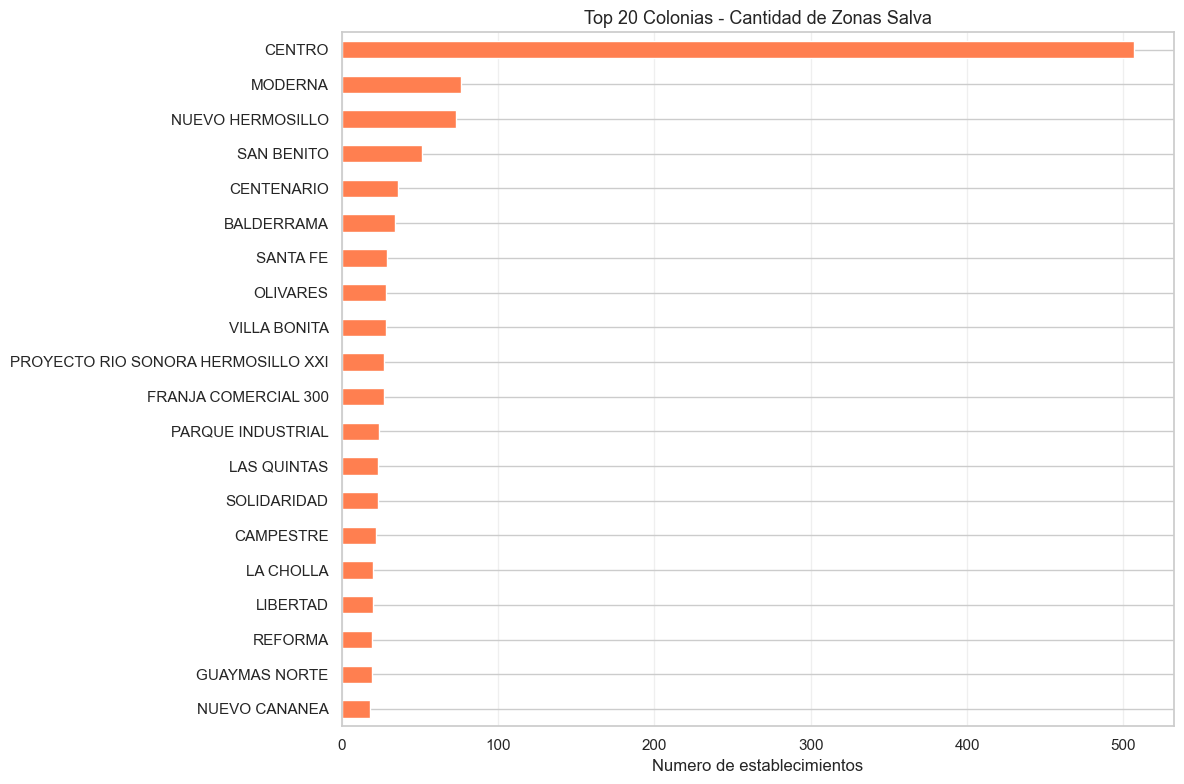


Estadisticas de concentracion por colonia:
  Colonias únicas: 32
  Mediana por colonia: 1
  Media por colonia: 4.09
  Máximo en una colonia: 507


In [9]:
# Colonias con mas establecimientos
col_dist = df_salva['COLONIA'].value_counts()

print(f"Top 20 colonias por cantidad de Zonas Salva:")
print(col_dist.head(20))

# Grafica
fig, ax = plt.subplots(figsize=(12, 8))
col_dist.head(20).sort_values(ascending=True).plot(kind='barh', ax=ax, color='coral')
ax.set_title('Top 20 Colonias - Cantidad de Zonas Salva', fontsize=13)
ax.set_xlabel('Numero de establecimientos')
ax.set_ylabel('')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\nEstadisticas de concentracion por colonia:")
print(f"  Colonias únicas: {col_dist.nunique()}")
print(f"  Mediana por colonia: {col_dist.median():.0f}")
print(f"  Media por colonia: {col_dist.mean():.2f}")
print(f"  Máximo en una colonia: {col_dist.max()}")

## 9. Cobertura Mensual - Cambios entre Enero y Febrero

Se comparan los dos meses disponibles para detectar cambios en el universo de establecimientos. Esto valida la estabilidad del dataset y verifica si hay variaciones estacionales o cambios de operacion.

In [10]:
# Cargar febrero nuevamente para comparacion
df_feb = pd.read_excel(RAW / "Zonas Salva febrero 2026.xlsx", sheet_name=0)

print(f"Comparacion de cobertura enero vs febrero:")
print(f"  Enero 2026: {len(df_ene)} establecimientos")
print(f"  Febrero 2026: {len(df_feb)} establecimientos")
print(f"  Diferencia: {len(df_feb) - len(df_ene)} ({((len(df_feb) - len(df_ene))/len(df_ene)*100):+.1f}%)")

# Municipios
mun_ene = set(df_ene['MUNICIPIO'].unique())
mun_feb = set(df_feb['MUNICIPIO'].unique())

print(f"\nMunicipios:")
print(f"  Enero: {len(mun_ene)}")
print(f"  Febrero: {len(mun_feb)}")

# Comparar distribucion
mun_ene_dist = df_ene['MUNICIPIO'].value_counts().head(10)
mun_feb_dist = df_feb['MUNICIPIO'].value_counts().head(10)

print(f"\nTop 5 municipios - Comparativa:")
comparativa = pd.DataFrame({
    'Enero': mun_ene_dist,
    'Febrero': mun_feb_dist
})
print(comparativa.fillna(0).astype(int))
print(f"\nInterpretacion: Base de datos estable entre meses, con cambios minimos en la cobertura.")

Comparacion de cobertura enero vs febrero:
  Enero 2026: 3132 establecimientos
  Febrero 2026: 3191 establecimientos
  Diferencia: 59 (+1.9%)

Municipios:
  Enero: 72
  Febrero: 72

Top 5 municipios - Comparativa:
                       Enero  Febrero
MUNICIPIO                            
CABORCA                   82       82
CAJEME                   576      576
CANANEA                  123      123
EMPALME                  140      138
GUAYMAS                  105      102
HERMOSILLO              1427     1456
NAVOJOA                   88       88
NOGALES                  153      153
PUERTO PEÑASCO            48       48
SAN LUIS RIO COLORADO    123      122

Interpretacion: Base de datos estable entre meses, con cambios minimos en la cobertura.


## 10. Resumen Ejecutivo - Hallazgos Clave

Se consolida el analisis de Zonas Salva en hallazgos clave. Este dataset, aunque staticoo y de menor dimension que otros, proporciona informacion sobre infraestructura de seguridad municipal y puede ser variable de contexto para enriquecer el modelo.

In [11]:
print("=" * 70)
print("RESUMEN EDA - ZONAS SALVA SONORA 2026")
print("=" * 70)

print(f"""
ESTRUCTURA
  - {len(df_salva)} establecimientos registrados (enero 2026)
  - {df_salva['MUNICIPIO'].nunique()} municipios cubiertos
  - {df_salva['COLONIA'].nunique()} colonias únicamente identificadas
  - 24 columnas: ubicacion, horarios por dia de semana
  - Datos geoespaciales: coordenadas latitud-longitud

DISTRIBUCION GEOGRAFICA
  - Concentracion urbana: Top 5 municipios = {(df_salva[df_salva['MUNICIPIO'].isin(mun_dist.head(5).index)].shape[0]/len(df_salva)*100):.1f}%
  - Municipios principales:
    * {mun_dist.index[0]}: {mun_dist.iloc[0]} establecimientos
    * {mun_dist.index[1]}: {mun_dist.iloc[1]} establecimientos
    * {mun_dist.index[2]}: {mun_dist.iloc[2]} establecimientos
  - Dispersión: {col_dist.nunique()} colonias diferentes

TIPOS DE ESTABLECIMIENTOS
  - Diversidad: {tipo_dist.nunique()} tipos diferentes
  - Dominante: {tipo_dist.index[0]} ({tipo_dist.iloc[0]} establecimientos, {tipo_dist.iloc[0]/len(df_salva)*100:.1f}%)
  - Segundo: {tipo_dist.index[1]} ({tipo_dist.iloc[1]} establecimientos)
  - Tercer: {tipo_dist.index[2]} ({tipo_dist.iloc[2]} establecimientos)

HORARIOS DE OPERACION
  - Establecimientos 24 horas: {df_salva['Es_24_horas'].sum()} ({df_salva['Es_24_horas'].sum()/len(df_salva)*100:.1f}%)
  - Con horarios limitados: {(~df_salva['Es_24_horas']).sum()} ({(~df_salva['Es_24_horas']).sum()/len(df_salva)*100:.1f}%)

CALIDAD DE DATOS
  - Completitud general: excelente (>99% en campos clave)
  - Valores nulos minimos en variables geograficas
  - Coordenadas: {(df_salva[['LATITUD', 'LONGITUD']].notna().all(axis=1).sum()/len(df_salva)*100):.1f}% completas

ESTABILIDAD TEMPORAL
  - Enero 2026: {len(df_ene)} establecimientos
  - Febrero 2026: {len(df_feb)} establecimientos
  - Variacion: {((len(df_feb) - len(df_ene))/len(df_ene)*100):+.1f}% (cambio minimo)
  - Base de datos estable para uso en modelo

USO PARA MODELADO
  - Densidad de Zonas Salva por municipio = proxy de infraestructura de seguridad
  - Ubicacion geoespacial = posible variable de contexto municipal
  - Tipos de lugar = caracterizacion de dinamica comercial/nocturna
  - No es variable predictora primaria, pero agrega contexto
""")

print("=" * 70)

RESUMEN EDA - ZONAS SALVA SONORA 2026

ESTRUCTURA
  - 3132 establecimientos registrados (enero 2026)
  - 72 municipios cubiertos
  - 762 colonias únicamente identificadas
  - 24 columnas: ubicacion, horarios por dia de semana
  - Datos geoespaciales: coordenadas latitud-longitud

DISTRIBUCION GEOGRAFICA
  - Concentracion urbana: Top 5 municipios = 77.2%
  - Municipios principales:
    * HERMOSILLO: 1427 establecimientos
    * CAJEME: 576 establecimientos
    * NOGALES: 153 establecimientos
  - Dispersión: 32 colonias diferentes

TIPOS DE ESTABLECIMIENTOS
  - Diversidad: 7 tipos diferentes
  - Dominante: COMERCIO (2120 establecimientos, 67.7%)
  - Segundo: GOBIERNO (458 establecimientos)
  - Tercer: RESTAURANTE (221 establecimientos)

HORARIOS DE OPERACION
  - Establecimientos 24 horas: 252 (8.0%)
  - Con horarios limitados: 2880 (92.0%)

CALIDAD DE DATOS
  - Completitud general: excelente (>99% en campos clave)
  - Valores nulos minimos en variables geograficas
  - Coordenadas: 100.0% 

## Conclusion

El dataset de Zonas Salva es simple pero informativo. Proporciona informacion sobre la infraestructura de establecimientos adheridos a programas de seguridad municipal. Aunque no es una variable predictora directa, puede servir como variable de contexto para caracterizar municipios: alta densidad de Zonas Salva puede indicar area comercial activa con mayor circulacion de personas (y potencialmente mayor exposicion a ciertos tipos de delito). La estabilidad de datos entre meses confirma confiabilidad para usos posteriores.